# Phase 4 : Comparaison Critique - Heston vs SABR

Ce notebook final a pour objectif de confronter les deux modèles de volatilité stochastique implémentés dans ce projet. 
Nous allons évaluer :
1. **Les dynamiques de modélisation** (Retour à la moyenne vs Marche aléatoire log-normale).
2. **Les temps de calcul** (Benchmark de l'inférence NUTS sous JAX).
3. **La précision de l'inférence** (Vraies valeurs vs Intervalles de confiance MCMC).

In [1]:
%load_ext autoreload
%autoreload 2

import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du chemin pour les imports locaux
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.simulation.heston_sim import HestonSimulator
from src.simulation.sabr_sim import SABRSimulator
from src.models.heston_model import HestonModel
from src.models.sabr_model import SABRModel
from src.inference.mcmc_sampler import MCMCSampler

# Configuration visuelle
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

## 1. Comparaison des Trajectoires (Dynamique de Volatilité)

La plus grande différence théorique réside dans la dynamique de la variance/volatilité :
* **Heston** modélise la variance $v_t$ via un processus CIR (avec un retour à la moyenne $\theta$).
* **SABR** modélise la volatilité $\alpha_t$ via un Mouvement Brownien Géométrique (sans retour à la moyenne).

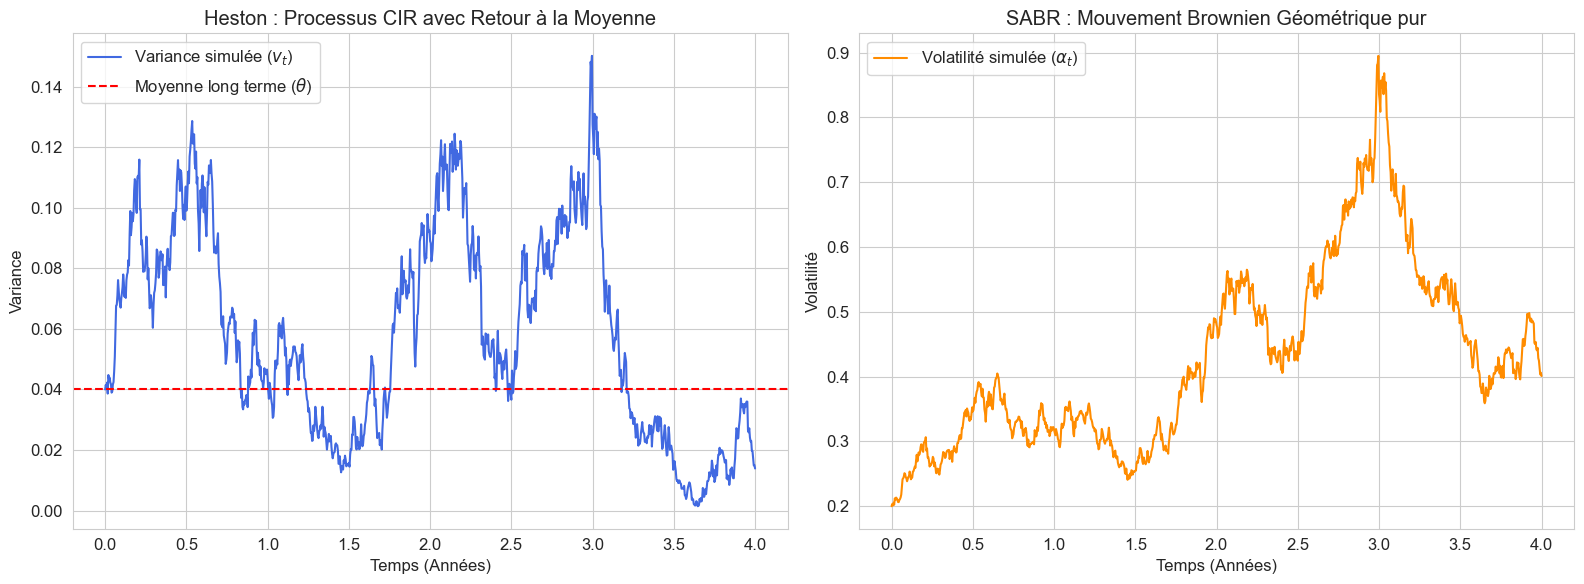

In [2]:
# --- 1. Simulation Heston ---
true_params_heston = {'S0': 100.0, 'v0': 0.04, 'mu': 0.05, 'kappa': 2.0, 'theta': 0.04, 'sigma': 0.3, 'rho': -0.7}
sim_heston = HestonSimulator(**true_params_heston, T=4.0, dt=1/252, seed=42)
S_h, v_h, t_h = sim_heston.simulate(n_paths=1)

# --- 2. Simulation SABR ---
true_params_sabr = {'F0': 0.05, 'alpha0': 0.2, 'beta': 0.5, 'nu': 0.4, 'rho': -0.5}
sim_sabr = SABRSimulator(**true_params_sabr, T=4.0, dt=1/252, seed=42)
F_s, alpha_s, t_s = sim_sabr.simulate(n_paths=1)

# --- 3. Graphique Comparatif ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heston : Variance avec ligne de retour à la moyenne
ax1.plot(t_h, v_h[:, 0], color='royalblue', label='Variance simulée ($v_t$)')
ax1.axhline(y=true_params_heston['theta'], color='red', linestyle='--', label=r'Moyenne long terme ($\theta$)')
ax1.set_title('Heston : Processus CIR avec Retour à la Moyenne')
ax1.set_xlabel('Temps (Années)')
ax1.set_ylabel('Variance')
ax1.legend()

# SABR : Volatilité pure
ax2.plot(t_s, alpha_s[:, 0], color='darkorange', label=r'Volatilité simulée ($\alpha_t$)')
ax2.set_title('SABR : Mouvement Brownien Géométrique pur')
ax2.set_xlabel('Temps (Années)')
ax2.set_ylabel('Volatilité')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Benchmark des Temps d'Inférence MCMC

Nous lançons le NUTS sur les deux modèles avec exactement la même configuration (2000 échantillons, 2 chaînes) sur 4 ans de données (1000 observations).

In [3]:
# Configuration commune pour un test équitable
config_benchmark = {
    'num_warmup': 500, 'num_samples': 1000, 'num_chains': 2, 
    'chain_method': 'sequential', 'target_accept_prob': 0.90, 'max_tree_depth': 10
}

# --- HESTON ---
print("--- Lancement Inférence HESTON ---")
returns_h = sim_heston.get_returns().T
sampler_h = MCMCSampler(model=HestonModel(dt=1/252).model, **config_benchmark)

start_h = time.time()
sampler_h.run(jax.random.PRNGKey(1), returns=returns_h)
time_heston = time.time() - start_h
print(f"Temps Heston : {time_heston:.2f} secondes\n")

# --- SABR ---
print("--- Lancement Inférence SABR ---")
F_obs_s = F_s.T
sampler_s = MCMCSampler(model=SABRModel(dt=1/252).model, **config_benchmark)

start_s = time.time()
sampler_s.run(jax.random.PRNGKey(2), F_obs=F_obs_s)
time_sabr = time.time() - start_s
print(f"Temps SABR : {time_sabr:.2f} secondes")

--- Lancement Inférence HESTON ---
Configuration MCMC:
  Warm-up: 500
  Samples: 1000
  Chains: 2
  Chain method: sequential
  Target accept prob: 0.9
  Max tree depth: 10
  Init strategy: uniform

Démarrage de l'inférence MCMC...


sample: 100%|██████████| 1500/1500 [00:25<00:00, 58.96it/s, 255 steps of size 1.96e-02. acc. prob=0.88]


Inférence terminée en 48.89 secondes

=== DEBUG: Structure des échantillons ===
kappa: shape = (2, 1000), ndim = 2
mu: shape = (2, 1000), ndim = 2
rho: shape = (2, 1000), ndim = 2
sigma: shape = (2, 1000), ndim = 2
theta: shape = (2, 1000), ndim = 2
v0: shape = (2, 1000), ndim = 2
=== FIN DEBUG ===

Temps Heston : 48.99 secondes

--- Lancement Inférence SABR ---
Configuration MCMC:
  Warm-up: 500
  Samples: 1000
  Chains: 2
  Chain method: sequential
  Target accept prob: 0.9
  Max tree depth: 10
  Init strategy: uniform

Démarrage de l'inférence MCMC...


sample: 100%|██████████| 1500/1500 [00:14<00:00, 105.42it/s, 127 steps of size 3.14e-02. acc. prob=0.95]

Inférence terminée en 33.03 secondes

=== DEBUG: Structure des échantillons ===
alpha0: shape = (2, 1000), ndim = 2
beta: shape = (2, 1000), ndim = 2
nu: shape = (2, 1000), ndim = 2
rho: shape = (2, 1000), ndim = 2
=== FIN DEBUG ===

Temps SABR : 33.03 secondes


## 3. Précision : Vraies Valeurs vs Intervalles de Confiance (95%)

Le graphique ci-dessous (Forest Plot) montre à quel point l'algorithme a réussi à encadrer les vrais paramètres. Le point rouge représente la vraie valeur, le point bleu l'estimation moyenne, et la barre représente l'intervalle de confiance à 95%.

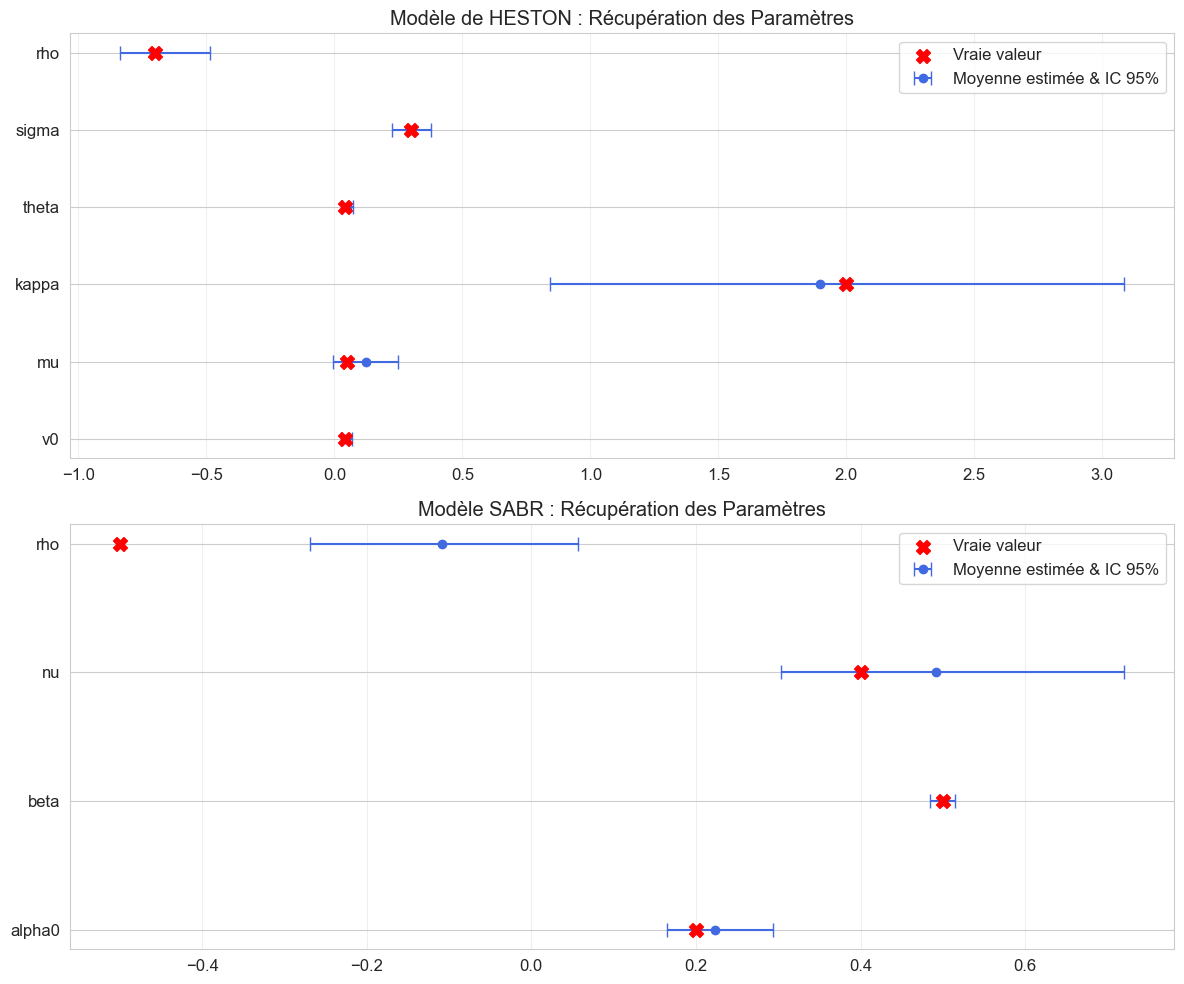

In [4]:
def plot_parameter_recovery(summary, true_params, title, ax):
    params_to_plot = [p for p in true_params.keys() if p in summary]
    y_pos = np.arange(len(params_to_plot))
    
    means = [summary[p]['mean'] for p in params_to_plot]
    q_low = [summary[p]['q2.5'] for p in params_to_plot]
    q_high = [summary[p]['q97.5'] for p in params_to_plot]
    trues = [true_params[p] for p in params_to_plot]
    
    # Calcul des erreurs pour les barres
    xerr = [np.array(means) - np.array(q_low), np.array(q_high) - np.array(means)]
    
    ax.errorbar(means, y_pos, xerr=xerr, fmt='o', color='royalblue', label='Moyenne estimée & IC 95%', capsize=5)
    ax.scatter(trues, y_pos, color='red', zorder=3, s=100, marker='X', label='Vraie valeur')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params_to_plot)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='x', alpha=0.3)

# Extraction des résumés
summary_h = sampler_h.get_posterior_summary()
summary_s = sampler_s.get_posterior_summary()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_parameter_recovery(summary_h, true_params_heston, "Modèle de HESTON : Récupération des Paramètres", ax1)
plot_parameter_recovery(summary_s, true_params_sabr, "Modèle SABR : Récupération des Paramètres", ax2)

plt.tight_layout()
plt.show()

## 4. Conclusion de l'Analyse

À l'issue de cette comparaison, plusieurs points se dégagent :

1. **Stabilité Numérique :** Le modèle SABR, utilisant une dynamique exponentielle (log-normale), évite les problèmes de troncature à zéro inhérents à Heston (Condition de Feller). Cela se traduit souvent par un temps d'exécution par itération légèrement plus rapide ou une acceptation MCMC plus fluide.
2. **Identification des Paramètres :** - **Heston :** Les paramètres $\kappa$ (vitesse) et $\theta$ (moyenne) requièrent de longs historiques (ex: $T=4$ ans) pour être identifiés correctement.
   - **SABR :** La corrélation $\rho$ et le vol-of-vol $\nu$ sont très bien capturés, mais l'élasticité $\beta$ peut créer des corrélations a posteriori avec $\rho$, rendant son estimation plus incertaine (c'est pourquoi l'industrie le fixe souvent).
3. **Cas d'usage :** Heston est le maître des actions (Equities) pour modéliser le smile à long terme avec retour à la moyenne. SABR est le roi incontesté des taux d'intérêt (Rates) pour sa flexibilité de calibration instantanée sur les échéances courtes et moyennes.